In [ ]:
# destinado a limpar os nomes da colunas
! pip install pyjanitor

In [ ]:

import pandas as pd
import numpy as np
import janitor  # Para a limpeza de nomes de colunas
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import warnings

# Configurações para melhor visualização
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Detecção e Tratamento de Outliers



## O que é um outlier
Pontos de dados que se afastam significativamente da média ou do padrão geral da distribuição. Podem ser erros de medição, erros de digitação ou anomalias reais e válidas do negócio.

## Como encontrar os pontos de corte (Métodos Matemáticos) para analise univariada



### Intervalo Interquartil (IQR)
É o método mais robusto e utilizado, pois não depende da média (que é afetada pelos próprios outliers). Baseia-se na mediana e nos quartis (box-plot). Temos o método Turkey que também cria uma categoria de dados extremos com o multiplicador 3 ao invés de 1.5.

* **Passo 1:** Calcular o Primeiro Quartil (Q1) -> O valor que separa os 25% menores dados.
* **Passo 2:** Calcular o Terceiro Quartil (Q3) -> O valor que separa os 75% menores dados.
* **Passo 3:** Calcular o IQR (Intervalo Interquartil) -> Subtrair Q1 de Q3 (IQR = Q3 - Q1).
* **Ponto de Corte Inferior:** Q1 - (1.5 * IQR)
* **Ponto de Corte Superior:** Q3 + (1.5 * IQR)
* **Diagnóstico:** Qualquer valor fora desses limites é considerado um outlier.

###  Z-Score (Desvio Padrão)
Assume que os dados seguem uma distribuição Normal (curva de sino). Mede a distância do ponto em relação à média.

* **Passo 1:** Calcular a Média da coluna.
* **Passo 2:** Calcular o Desvio Padrão da coluna.
* **Passo 3:** Definir o limite (Threshold). O padrão da indústria é 3.
* **Cálculo:** Se (Valor - Média) / Desvio Padrão > 3 (ou < -3), é um outlier.
* **Diagnóstico:** Pontos que estão a mais de 3 desvios padrão de distância da média.



In [ ]:
#Carregando os dados do Titanic
# Utilizamos o pyjanitor para limpar os nomes das colunas
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url).clean_names()


print(df.head())

   passengerid  survived  pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                name     sex   age  sibsp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   parch            ticket     fare cabin embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


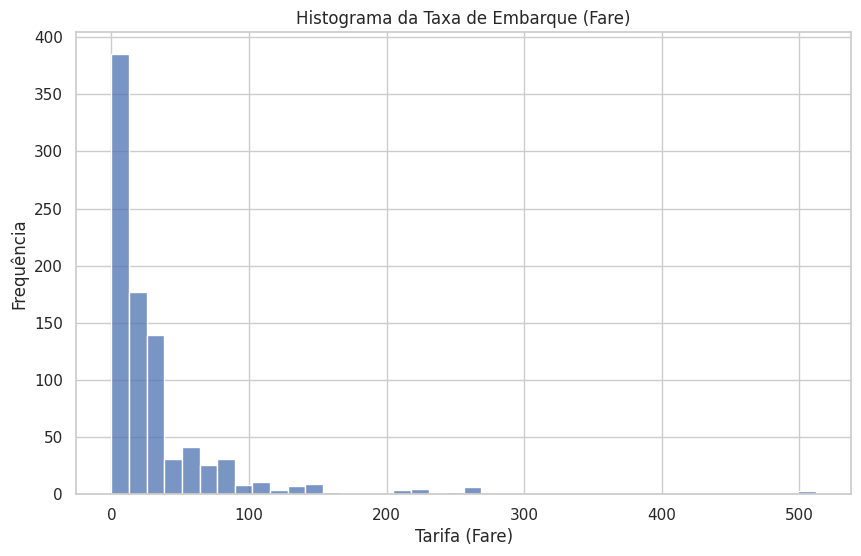

In [ ]:
# Histograma da taxa de embarque
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fare', bins=40)
plt.title('Histograma da Taxa de Embarque (Fare)')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frequência')
plt.show()

Valores dos quantis para a tarifa:
0.90     77.95830
0.95    112.07915
0.99    249.00622
Name: fare, dtype: float64


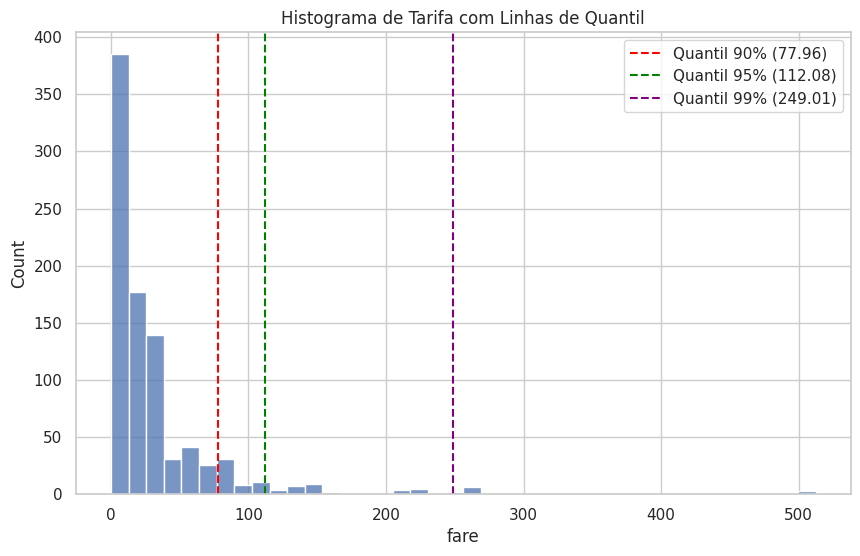

In [ ]:
# >>>>>>>>>>Análise de Outliers por Quantis<<<<<<<<<<<<<<<<<<<
quantiles_var = df['fare'].quantile([0.90, 0.95, 0.99]).dropna()

print("Valores dos quantis para a tarifa:")
print(quantiles_var)

# Gráfico com linhas de quantil
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fare', bins=40)
colors = ['red', 'green', 'purple']
for i, (index, value) in enumerate(quantiles_var.items()):
    plt.axvline(x=value, color=colors[i], linestyle='--', label=f"Quantil {index*100:.0f}% ({value:.2f})")

plt.title('Histograma de Tarifa com Linhas de Quantil')
plt.legend()
plt.show()

Q1: 7.91, Q3: 31.00, IQR: 23.09
Limite Inferior: -26.72
Limite Superior: 65.63


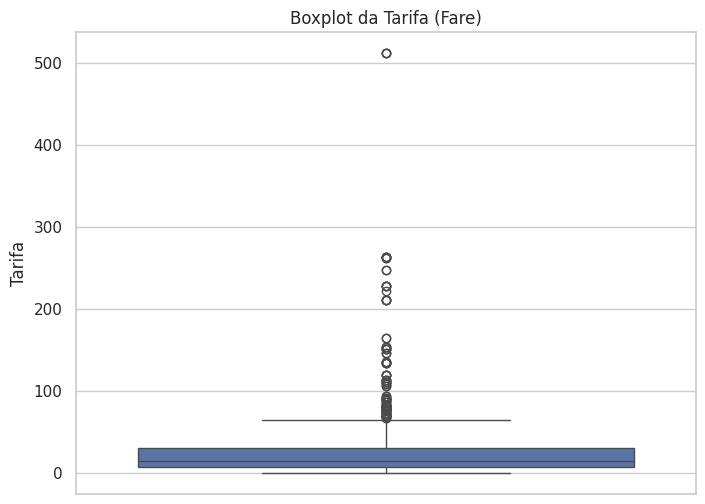


Encontrados 116 outliers usando o método IQR.
Amostra de outliers:
    passengerid  survived  pclass  \
1             2         1       1   
27           28         0       1   
31           32         1       1   
34           35         0       1   
52           53         1       1   

                                                 name     sex   age  sibsp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
27                     Fortune, Mr. Charles Alexander    male  19.0      3   
31     Spencer, Mrs. William Augustus (Marie Eugenie)  female   NaN      1   
34                            Meyer, Mr. Edgar Joseph    male  28.0      1   
52           Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   

    parch    ticket      fare        cabin embarked  
1       0  PC 17599   71.2833          C85        C  
27      2     19950  263.0000  C23 C25 C27        S  
31      0  PC 17569  146.5208          B78        C  
34      0  PC 17604   82

In [ ]:
#>>>>>>>>>>>>>>>Análise de Outliers usando IQR (Boxplot)<<<<<<<<<<<<<<<<<
# Cálculo dos limites (bounds)
q1_fare = df['fare'].quantile(0.25)
q3_fare = df['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
lower_bound_fare = q1_fare - 1.5 * iqr_fare
upper_bound_fare = q3_fare + 1.5 * iqr_fare

print(f"Q1: {q1_fare:.2f}, Q3: {q3_fare:.2f}, IQR: {iqr_fare:.2f}")
print(f"Limite Inferior: {lower_bound_fare:.2f}")
print(f"Limite Superior: {upper_bound_fare:.2f}")


#Boxplot com a identificação dos outliers
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='fare')
plt.title('Boxplot da Tarifa (Fare)')
plt.ylabel('Tarifa')
plt.show()

# Encontrar e exibir os outliers
outliers_iqr = df[(df['fare'] < lower_bound_fare) | (df['fare'] > upper_bound_fare)]
print(f"\nEncontrados {len(outliers_iqr)} outliers usando o método IQR.")
print("Amostra de outliers:")
print(outliers_iqr.head())

In [ ]:
# >>>>>>>>>>>Método de Tukey<<<<<<<<<<<<<
# Semelhante ao IQR, mas com um multiplicador maior (geralmente 3)
tukey_lower_bound = q1_fare - 3 * iqr_fare
tukey_upper_bound = q3_fare + 3 * iqr_fare

print(f"Limite Inferior: {tukey_lower_bound:.2f}")
print(f"Limite Superior: {tukey_upper_bound:.2f}")

Limite Inferior: -61.36
Limite Superior: 100.27


Limites calculados:
        value            method
0  181.284494  3x Desvio Padrão
1   35.166800            3x MAD


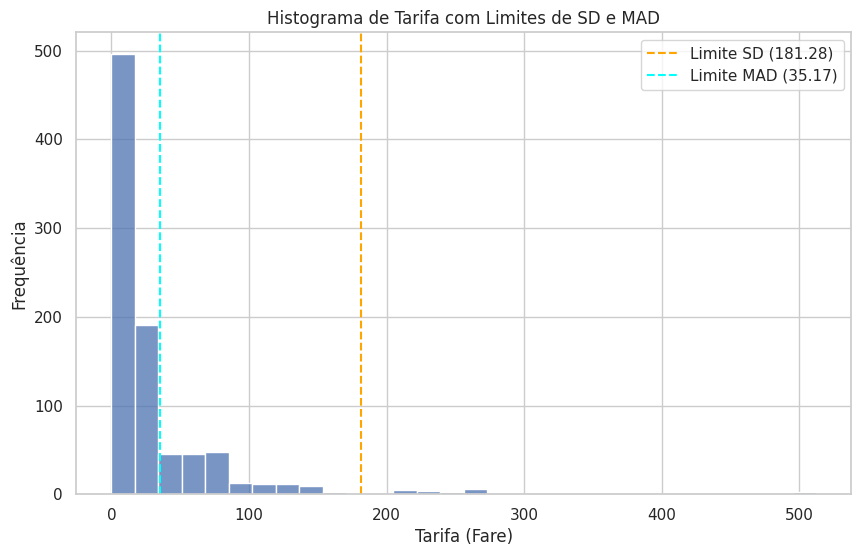

In [ ]:
# >>>>>>>>>>>>Analise com Desvio Padrão(Z-Score) e MAD <<<<<<<<<<<<<

#Usando Desvio Padrão (distribuição proximas ao normal)
media_fare = df['fare'].mean()
desvio_padrao_fare = df['fare'].std()
limite_superior_sd = media_fare + 3 * desvio_padrao_fare
limite_inferior_sd = media_fare - 3 * desvio_padrao_fare

# Usando MAD (Median Absolute Deviation)
# A biblioteca SciPy oferece uma função direta para isso
mad_fare = stats.median_abs_deviation(df['fare'].dropna())
mediana_fare = df['fare'].median()
limite_superior_mad = mediana_fare + 3 * mad_fare

df_p_sd_mad = pd.DataFrame({
    'value': [limite_superior_sd, limite_superior_mad],
    'method': ['3x Desvio Padrão', '3x MAD']
})

print("Limites calculados:")
print(df_p_sd_mad)

## >>>>>>>>>>>>Z-Score<<<<<<<<<<<<<<<

df_numerical = df.select_dtypes(include=np.number)
z_df = df_numerical.apply(stats.zscore) # zscore
df_filtered = df[(z_df < 3).all(axis=1)] #filtro

##>>>>>>>>>>
# Gráfico com os limites
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fare', bins=30)
plt.axvline(x=limite_superior_sd, color='orange', linestyle='--', label=f"Limite SD ({limite_superior_sd:.2f})")
plt.axvline(x=limite_superior_mad, color='cyan', linestyle='--', label=f"Limite MAD ({limite_superior_mad:.2f})")
plt.title('Histograma de Tarifa com Limites de SD e MAD')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frequência')
plt.legend()
plt.show()


# Detecção de Outliers Multivariados

## O que são
São observações que parecem normais quando analisadas separadamente em cada variável, mas que se tornam anômalas quando analisamos a combinação (correlação) entre duas ou mais variáveis.

* **Exemplo:**
  * Variável A (Idade): 10 anos (Normal).
  * Variável B (Salário): R$ 20.000,00 (Normal para um executivo).
  * Combinação (A + B): Uma criança de 10 anos ganhando 20 mil é um Outlier Multivariado.

## Principais Métodos de Detecção

Além de recursos visuais como como plots de dispersão e ou por blocos, temos alguns métodos computacionais.

### Distância de Mahalanobis
É uma extensão da distância Euclidiana que leva em conta a correlação entre as variáveis.

* **Conceito:** Mede a distância de um ponto até o centro da distribuição (centroide), considerando o "formato" da nuvem de dados (matriz de covariância).
* **Vantagem:** Consegue detectar pontos que quebram o padrão de correlação (ex: Peso aumenta conforme Altura aumenta; um ponto com Altura alta e Peso baixo terá alta distância de Mahalanobis).
* **Critério de Corte:** Utiliza-se geralmente a distribuição Qui-quadrado para definir o limiar de corte.

### Isolation Forest (Floresta de Isolamento)
Um algoritmo de aprendizado de máquina não supervisionado, baseado em árvores de decisão.

* **Conceito:** Parte do princípio de que anomalias são raras e diferentes. Portanto, é mais fácil "isolar" um outlier do que isolar um ponto normal.
* **Funcionamento:** O algoritmo cria cortes aleatórios nos dados.
  * Pontos normais (que estão aglomerados) precisam de muitos cortes para ficarem sozinhos.
  * Outliers (que estão afastados) precisam de poucos cortes para serem isolados.
* **Critério:** Se o caminho da raiz até a folha da árvore for curto, o ponto é classificado como outlier.

### LOF (Local Outlier Factor)
Um método baseado na densidade dos vizinhos (similar à lógica do KNN).

* **Conceito:** Compara a densidade local de um ponto com a densidade local dos seus vizinhos (k-vizinhos).
* **Funcionamento:**
  * Se a densidade do ponto é similar à dos vizinhos, ele é um ponto normal (inlier).
  * Se a densidade do ponto é muito menor que a dos seus vizinhos (ele está isolado enquanto os vizinhos estão agrupados), ele é um outlier.
* **Vantagem:** Eficiente para detectar outliers locais em dados que formam clusters de densidades diferentes.

###  DBSCAN (Clustering)
Algoritmo de agrupamento espacial baseado em densidade.

* **Conceito:** O algoritmo tenta agrupar pontos próximos.
* **Funcionamento:** Pontos que estão em regiões de baixa densidade e não conseguem ser associados a nenhum cluster principal são rotulados como "Ruído" (-1).
* **Uso:** Esses pontos classificados como ruído são, efetivamente, os outliers multivariados.

Exemplos, iniciando pelo media de blocos (recurso visual)

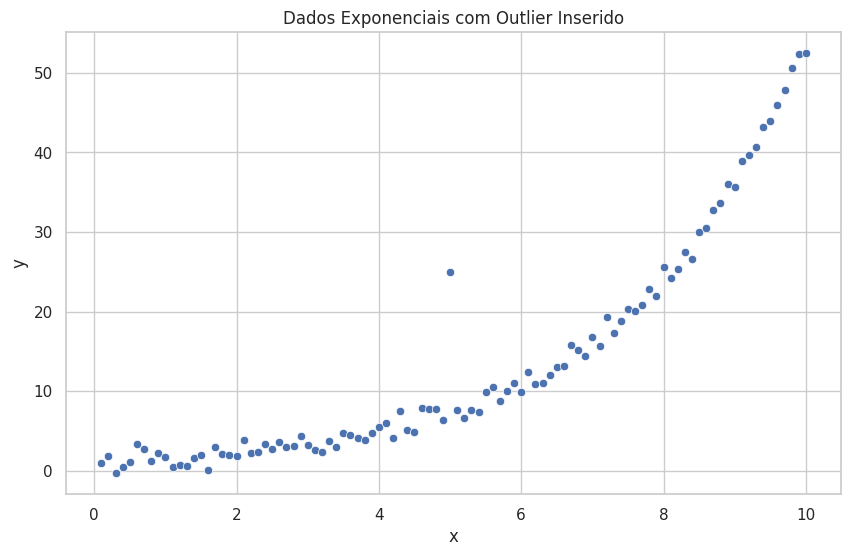

In [ ]:
# Função exponencial com ruido
np.random.seed(2025)
x = np.linspace(0.1, 10, 100)
y = 1 * np.exp(0.4 * x) + np.random.normal(0, 1, 100)

# Inserir outlier
x[49] = 5
y[49] = 25

dados_exp = pd.DataFrame({'x': x, 'y': y})



# Visualização inicial dos dados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_exp, x='x', y='y')
plt.title('Dados Exponenciais com Outlier Inserido')
plt.show()


Dados com outliers identificados por categoria:
      x     y categoria   status
49  5.0  25.0    (4, 5]  Outlier


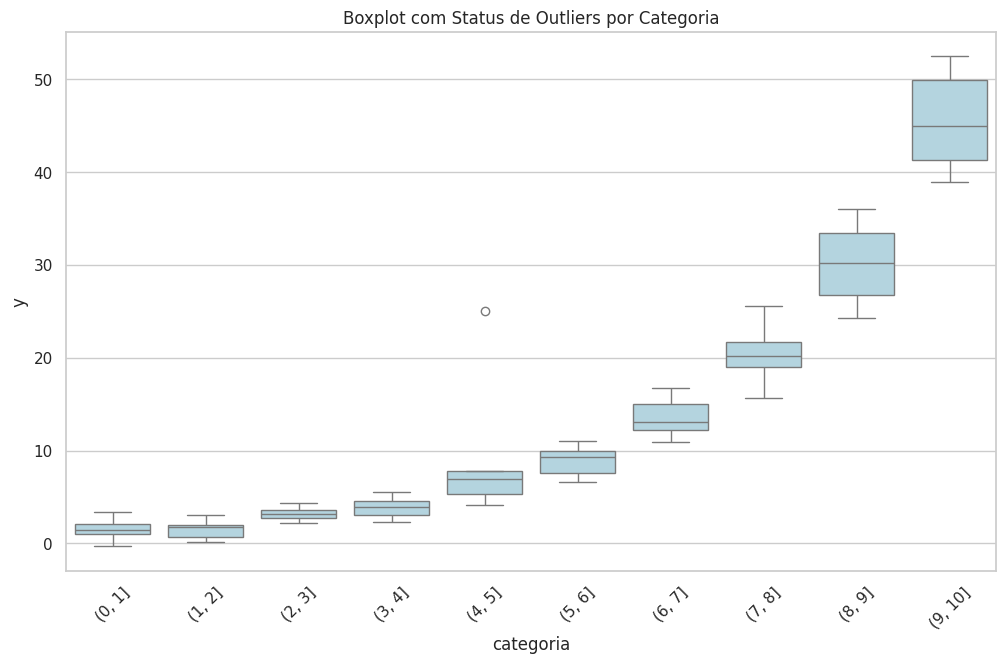

In [ ]:
# >>>>>>>>>>  Detecção de Outliers por Blocos <<<<<<<<<<<<

#>>>>>> aplicavel apenas na relação entre duas variaveis

# Adiciona uma coluna de categoria baseada nos valores de x
dados_exp['categoria'] = pd.cut(dados_exp['x'], bins=range(0, 11))

# Função para calcular os limites e identificar outliers
def find_outliers_group(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (group < lower_bound) | (group > upper_bound)

# Aplica a função a cada grupo de categoria
outliers_per_group = dados_exp.groupby('categoria')['y'].transform(find_outliers_group)
dados_exp['status'] = np.where(outliers_per_group, 'Outlier', 'Normal')

print("\nDados com outliers identificados por categoria:")
print(dados_exp[dados_exp['status'] == 'Outlier'])

# --- Boxplot por categoria ---
plt.figure(figsize=(12, 7))
sns.boxplot(data=dados_exp, x='categoria', y='y', color="lightblue")
#sns.stripplot(data=dados_exp, x='categoria', y='y', hue='status', palette={'Normal': 'black', 'Outlier': 'red'}, dodge=True)
plt.title('Boxplot com Status de Outliers por Categoria')
plt.xticks(rotation=45)
plt.show()

# Isolation forest

Dados com classificação da Floresta de Isolação:
       x         y outlier_if    scores
49   5.0  25.00000    Outlier -0.002079
99  10.0  52.46622    Outlier -0.023075


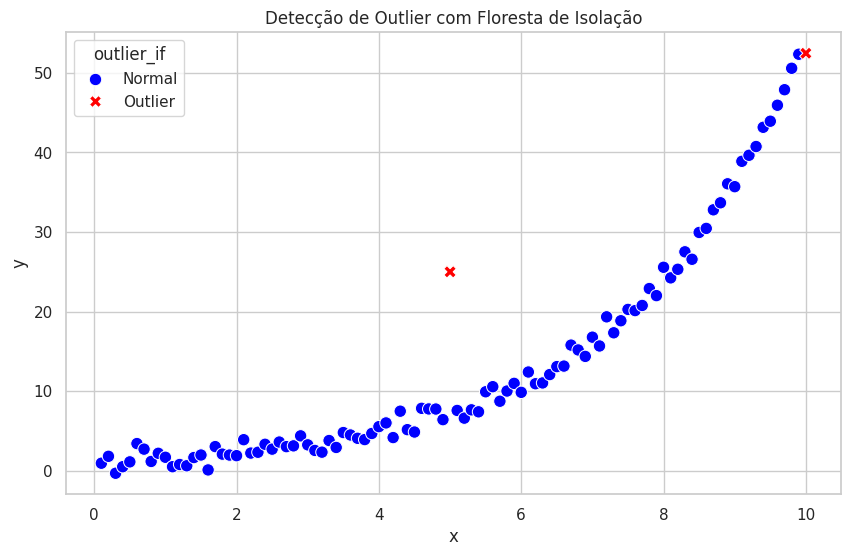

In [ ]:
# Exemplo de dados para Análise Multivariada
# Função exponencial com ruido
np.random.seed(2025)
x = np.linspace(0.1, 10, 100)
y = 1 * np.exp(0.4 * x) + np.random.normal(0, 1, 100)

# Inserir outlier
x[49] = 5
y[49] = 25
x[51] = 5.1
y[51] = 25.2

dados_exp = pd.DataFrame({'x': x, 'y': y})


#  >>>>>>>  Floresta de Isolação <<<<<<<<
# O modelo identificará os pontos que são "mais fáceis de isolar"
modelo_if = IsolationForest(contamination=0.02, random_state=2025,n_estimators=500) # contamination sugere a proporção de outliers
outliers_if = modelo_if.fit_predict(dados_exp)
scores = modelo_if.decision_function(dados_exp)

# -1 indica outlier, 1 indica inlier (normal)
dados_exp['outlier_if'] = np.where(outliers_if == -1, 'Outlier', 'Normal')
dados_exp['scores'] = scores
print("Dados com classificação da Floresta de Isolação:")
print(dados_exp[dados_exp['outlier_if'] == 'Outlier'])


# --- Gráfico dos resultados ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_exp, x='x', y='y', hue='outlier_if', palette={'Normal': 'blue', 'Outlier': 'red'}, style='outlier_if', s=80)
plt.title('Detecção de Outlier com Floresta de Isolação')
plt.show()

Note que definir o ponto de corte de maneira automatica pode não ser a melhor escolha, podemos usar de forma manual baseado no scores.

In [ ]:
# valores para definição do ponto de corte
scores

array([ 6.97116495e-02,  9.44375188e-02,  3.34446837e-02,  1.07392002e-01,
        1.31190711e-01,  9.43666651e-02,  1.29876120e-01,  1.42107885e-01,
        1.55474960e-01,  1.62624898e-01,  1.36959532e-01,  1.46433748e-01,
        1.44032715e-01,  1.68564252e-01,  1.81706157e-01,  8.81358356e-02,
        1.68370821e-01,  1.89673756e-01,  1.89088899e-01,  1.80596151e-01,
        1.54335921e-01,  1.88760032e-01,  1.90807782e-01,  1.91068425e-01,
        1.91079368e-01,  1.87305874e-01,  1.99860956e-01,  2.00106971e-01,
        1.68093086e-01,  1.98961332e-01,  1.83994653e-01,  1.72062041e-01,
        1.95518675e-01,  1.82796950e-01,  1.84015993e-01,  1.96364591e-01,
        1.99986076e-01,  1.96214290e-01,  1.97298827e-01,  1.81292734e-01,
        1.72501314e-01,  1.81743250e-01,  1.59854636e-01,  1.81250472e-01,
        1.79414877e-01,  1.72654628e-01,  1.85284887e-01,  1.86112277e-01,
        1.74329711e-01, -4.82373381e-03,  1.89630221e-01,  1.75284592e-01,
        1.89225428e-01,  

# DBSCAN


Outliers identificados pelo DBSCAN:
      x     y
49  5.0  25.0


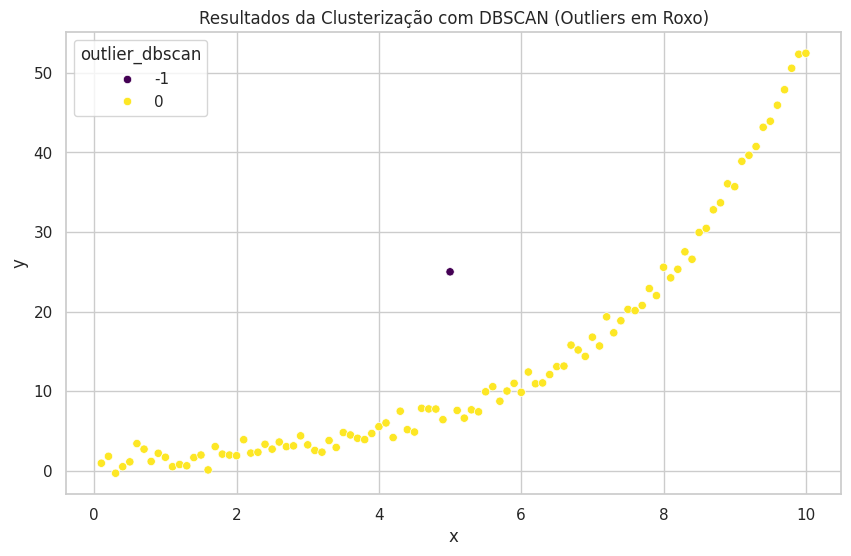

In [ ]:
### >>>>>>>>>>>>>> DBSCAN <<<<<<<<<<<<<<<<<<<

# Função exponencial com ruido
np.random.seed(2025)
x = np.linspace(0.1, 10, 100)
y = 1 * np.exp(0.4 * x) + np.random.normal(0, 1, 100)

# Inserir outlier
x[49] = 5
y[49] = 25
x[48] = 5.1
y[48] = 25
x[47] = 5.2
y[47] = 25

dados_exp = pd.DataFrame({'x': x, 'y': y})

#Normaliza os dados para o DBSCAN, obrigatorio

X_scaled = StandardScaler().fit_transform(dados_exp[['x', 'y']])

# Instancia e ajusta o modelo
# 'eps'(Raio maximo para considerar um ponto pertencente a um cluster) é o parâmetro mais crucial a ser ajustado. Quanto maior mais criterioso sera
# "min_samples" numero minimo de pontos para computar uma densidade
dbscan = DBSCAN(eps=0.5, min_samples=5) # declaro o modelo
clusters = dbscan.fit_predict(X_scaled) # treino o modelo

# O DBSCAN rotula outliers como -1
dados_exp['outlier_dbscan'] = clusters
outliers_dbscan = dados_exp[dados_exp['outlier_dbscan'] == -1]

print(f"\nOutliers identificados pelo DBSCAN:")
print(outliers_dbscan[['x', 'y']])

# Visualização do resultado do DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_exp, x='x', y='y', hue='outlier_dbscan', palette='viridis')
plt.title('Resultados da Clusterização com DBSCAN (Outliers em Roxo)')
plt.show()

#LOF


Outliers identificados pelo Local Outlier Factor (LOF):
      x     y     score
49  5.0  25.0 -2.051069


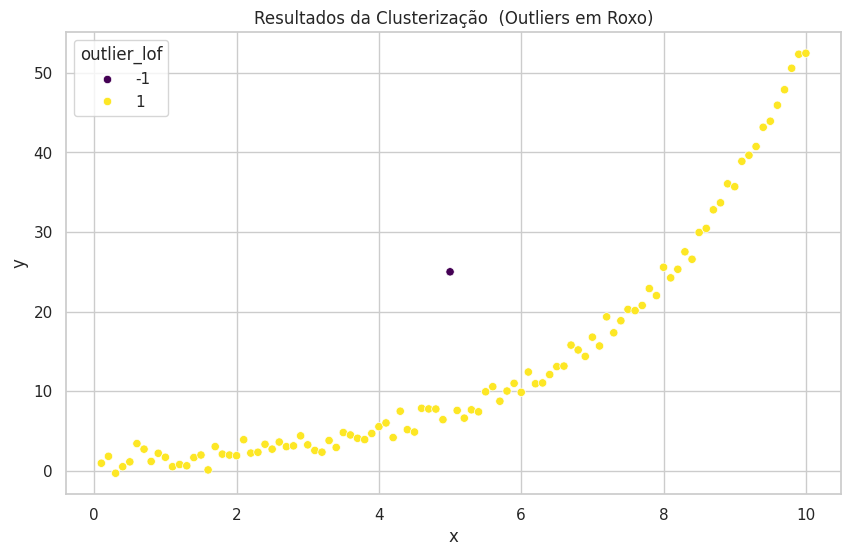

In [ ]:
#>>>>>>>>>>> LocalOutlierFactor<<<<<<<<<<<


# Função exponencial com ruido
np.random.seed(2025)
x = np.linspace(0.1, 10, 100)
y = 1 * np.exp(0.4 * x) + np.random.normal(0, 1, 100)

# Inserir outlier
x[49] = 5
y[49] = 25
x[48], y[48] = 5.1, 25
#x[47] = 5.2
#y[47] = 25


dados_exp = pd.DataFrame({'x': x, 'y': y})

# Normaliza os dados, obrigatorio
X_scaled = StandardScaler().fit_transform(dados_exp[['x', 'y']])

# Instancia o modelo. 'contamination' define a proporção esperada de outliers, ou seja vai ter algo.
lof = LocalOutlierFactor(n_neighbors=15, contamination="auto",)
outliers_lof = lof.fit_predict(X_scaled)

X_scores = lof.negative_outlier_factor_ # quanto estranho é o valor
# as vezes é bom usar esse valor para corte

# LOF também rotula outliers como -1
dados_exp['outlier_lof'] = outliers_lof
dados_exp['score']= X_scores
outliers_lof_df = dados_exp[dados_exp['outlier_lof'] == -1]
#manual
#corte_manual=-1.5
#df['Classificacao'] = df['Score'].apply(lambda s: 'Outlier' if s < corte_manual else 'Normal')


print(f"\nOutliers identificados pelo Local Outlier Factor (LOF):")
print(outliers_lof_df[['x', 'y','score']])

# Visualização do resultado
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_exp, x='x', y='y', hue='outlier_lof', palette='viridis')
plt.title('Resultados da Clusterização  (Outliers em Roxo)')
plt.show()

In [ ]:
Da mesma forma do isolationforest, recomendo verirficar os scores manualmente.

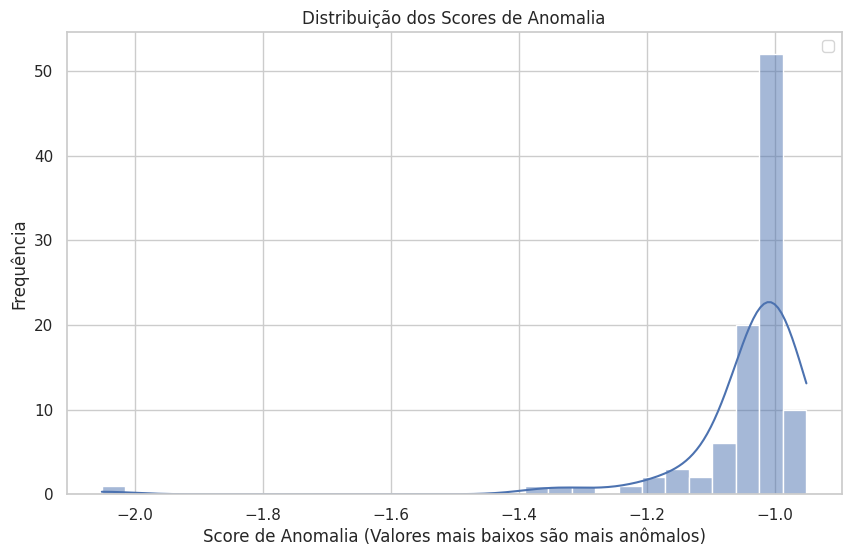

array([-1.19900353, -1.15732372, -1.1313195 , -1.09180334, -1.07380466,
       -1.06662307, -1.05369072, -1.06034174, -1.03191266, -1.01253555,
       -1.00205913, -0.98385892, -0.96912477, -0.95677861, -0.95676128,
       -0.95069758, -0.97905242, -0.97893526, -0.99476723, -0.99660349,
       -0.99049526, -1.00087579, -0.98929889, -0.99128303, -0.99323826,
       -0.99560074, -0.99416729, -0.99627434, -0.99428026, -0.98834313,
       -0.98919212, -0.99255895, -0.99847608, -0.9976445 , -1.00109598,
       -0.99467478, -0.99404416, -0.99031034, -1.00537282, -0.99867004,
       -1.00581654, -1.00557679, -1.02050629, -1.01167865, -1.01243261,
       -1.00724484, -0.99449866, -1.00043127, -0.9978119 , -2.05106898,
       -0.9862381 , -0.98430138, -1.0086796 , -1.00394572, -1.01477381,
       -1.00187601, -1.00006575, -0.99845721, -1.0006969 , -0.99749973,
       -0.98339936, -0.99453424, -0.99680993, -0.99927757, -1.00521156,
       -1.01397413, -1.00028929, -1.01597989, -1.03142624, -1.01

In [ ]:

# Visualizando a Distribuição dos Scores
plt.figure(figsize=(10, 6))
sns.histplot(dados_exp['score'], bins=30, kde=True)
plt.title('Distribuição dos Scores de Anomalia')
plt.xlabel('Score de Anomalia (Valores mais baixos são mais anômalos)')
plt.ylabel('Frequência')

plt.legend()
plt.show()
X_scores

## Distancia de Mahlanobis

Outliers detectados (99%): 1 pontos
    Mahalanobis_sq  outlier
41       10.190882     True


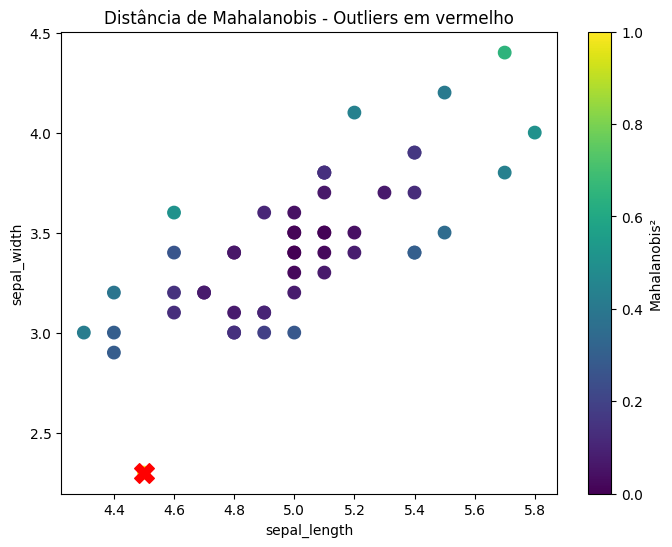

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
import matplotlib.pyplot as plt

# Exemplo com dados reais (dataset iris só para demonstração)
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
X = df[df.species == "setosa"][["sepal_length", "sepal_width"]].values

#  Calcular média e matriz de covariância
mu = X.mean(axis=0)
cov = np.cov(X.T)#calcula covariancia, .T é a transposta
inv_cov = np.linalg.inv(cov)#Calcula a inversa da matriz de covariância

# Calcular distância de Mahalanobis para cada ponto
diff = X - mu #Subtrai a média de cada ponto (centraliza os dados)
mahala = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1)) # Faz a multiplicação matricial

# Definir threshold (chi² com 95% ou 99%)
threshold_99 = chi2.ppf(0.99, df=X.shape[1])   # 2 variáveis,graus de liberdade = 2
outliers = mahala > np.sqrt(threshold_99)

#Resultado
print(f"Outliers detectados (99%): {sum(outliers)} pontos")
df_out = pd.DataFrame({"Mahalanobis_sq": mahala**2, "outlier": outliers})
print(df_out[outliers])

# Gráfico
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=mahala**2, cmap="viridis", s=80)
plt.scatter(X[outliers,0], X[outliers,1], c="red", s=200, marker="X")
plt.colorbar(label="Mahalanobis²")
plt.title("Distância de Mahalanobis - Outliers em vermelho")
plt.xlabel("sepal_length"); plt.ylabel("sepal_width")
plt.show()

## Atividade 1: para o dado anterior do iris, aplique outro modelo para identificar o mesmo outlier.



```
# precisamos primeiro converter 'X' em um DataFrame Pandas.
X_df = pd.DataFrame(X, columns=['sepal_length', 'sepal_width'])
```


Outliers identificados pelo DBSCAN:
    sepal_length  sepal_width  outlier_dbscan
41           4.5          2.3              -1


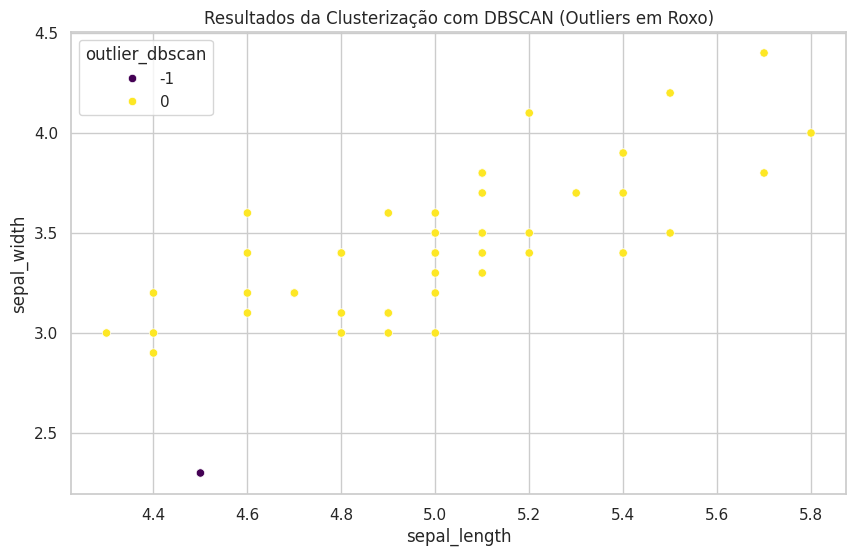

In [ ]:
# precisamos primeiro converter 'X' em um DataFrame Pandas.
X_df = pd.DataFrame(X, columns=['sepal_length', 'sepal_width'])

#Normaliza os dados para o DBSCAN
X_scaled = StandardScaler().fit_transform(X)

# Instancia e ajusta o modelo
# 'eps'(Raio maximo para considerar um ponto pertencente a um cluster) é o parâmetro mais crucial a ser ajustado. Quanto maior mais criterioso sera
# "min_samples" numero minimo de pontos para computar uma densidade
dbscan = DBSCAN(eps=1, min_samples=5) # declaro o modelo
clusters = dbscan.fit_predict(X_scaled) # treino o modelo

# O DBSCAN rotula outliers como -1

X_df['outlier_dbscan'] = clusters
outliers_dbscan = X_df[X_df['outlier_dbscan'] == -1]

print(f"\nOutliers identificados pelo DBSCAN:")
print(outliers_dbscan)


# Visualização do resultado do DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_df, x='sepal_length', y='sepal_width', hue='outlier_dbscan', palette='viridis')
plt.title('Resultados da Clusterização com DBSCAN (Outliers em Roxo)')
plt.show()

## Atividade 2: Analise os dados de consumidores de um shopping com os algoritmos de identificação de outliers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# 1. Carregando Dados Reais (Direto do Repositório)
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)


# Renomeando para facilitar (removendo espaços e unidades)
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'
}, inplace=True)

# Selecionando as features para o estudo
X = df[['Income', 'Score']]

# Pré-processamento: Escalonamento (Obrigatório para DBSCAN/LOF)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### O resto é por sua conta.

### Resposta

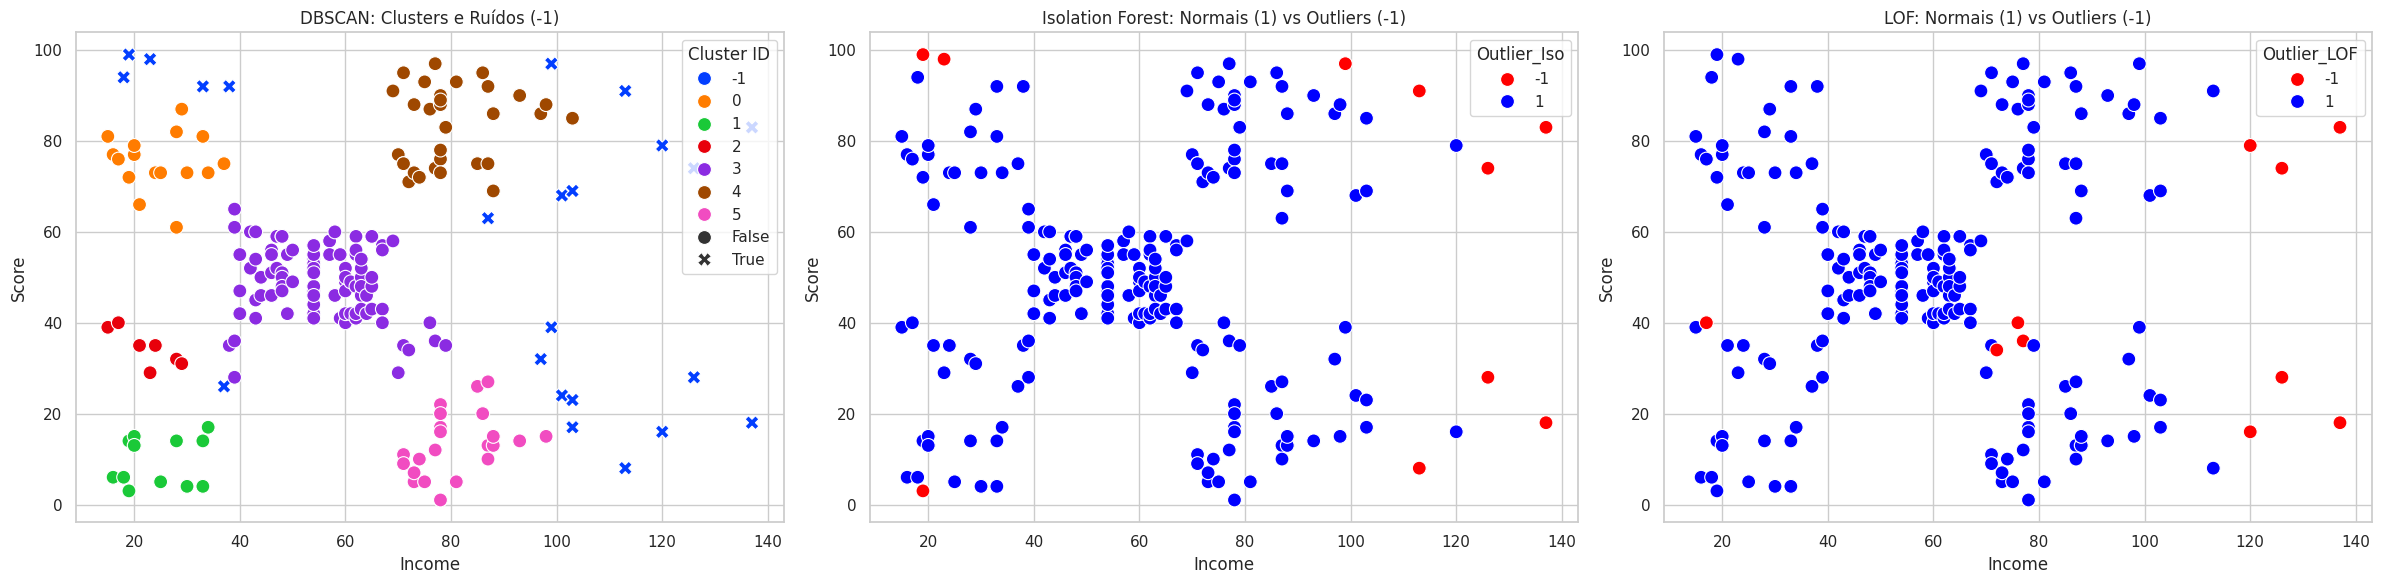


=== ANÁLISE DOS OUTLIERS (DBSCAN) ===
Total de Outliers detectados pelo DBSCAN: 23

=== ANÁLISE DOS OUTLIERS (ISO) ===
Total de Outliers detectados pelo ISO: 10

=== ANÁLISE DOS OUTLIERS (LOF) ===
Total de Outliers detectados pelo LOF: 10


In [ ]:
# MODELO 1: DBSCAN
# eps=0.35: Raio da vizinhança
# min_samples=5: Precisa de 5 vizinhos para ser um cluster
dbscan = DBSCAN(eps=0.35, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# MODELO 2: ISOLATION FOREST
# contamination=0.05: Assumimos que 5% dos clientes são anômalos
iso = IsolationForest(contamination=0.05, random_state=2025)
labels_iso = iso.fit_predict(X_scaled)

#  MODELO 3: LOCAL OUTLIER FACTOR
# n_neighbors=20: Compara com 20 vizinhos
# contamination=0.05: Mesma taxa de contaminação do IsoForest
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X_scaled)

# Adicionando ao DataFrame para plotar
df['Cluster_DBSCAN'] = labels_dbscan
df['Outlier_Iso'] = labels_iso
df['Outlier_LOF'] = labels_lof

# VISUALIZAÇÃO
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Plot DBSCAN
# -1 significa Ruído/Outlier no DBSCAN
sns.scatterplot(data=df, x='Income', y='Score', hue='Cluster_DBSCAN',
                palette='bright', ax=axes[0], style=(labels_dbscan == -1),
                markers={True: 'X', False: 'o'}, s=100)
axes[0].set_title('DBSCAN: Clusters e Ruídos (-1)')
axes[0].legend(title='Cluster ID')

# Plot Isolation Forest
# -1 significa Outlier no IsoForest
sns.scatterplot(data=df, x='Income', y='Score', hue='Outlier_Iso',
                palette={1: 'blue', -1: 'red'}, ax=axes[1], s=100)
axes[1].set_title('Isolation Forest: Normais (1) vs Outliers (-1)')

# Plot LOF
# -1 significa Outlier no LOF
sns.scatterplot(data=df, x='Income', y='Score', hue='Outlier_LOF',
                palette={1: 'blue', -1: 'red'}, ax=axes[2], s=100)
axes[2].set_title('LOF: Normais (1) vs Outliers (-1)')

plt.tight_layout()
plt.show()

# --- QUEM SÃO OS OUTLIERS---
print("\n=== ANÁLISE DOS OUTLIERS (DBSCAN) ===")
outliers = df[df['Cluster_DBSCAN'] == -1]
print(f"Total de Outliers detectados pelo DBSCAN: {len(outliers)}")


print("\n=== ANÁLISE DOS OUTLIERS (ISO) ===")
outliers_iso = df[df['Outlier_Iso'] == -1]
print(f"Total de Outliers detectados pelo ISO: {len(outliers_iso)}")

print("\n=== ANÁLISE DOS OUTLIERS (LOF) ===")
outliers_lof = df[df['Outlier_LOF'] == -1]
print(f"Total de Outliers detectados pelo LOF: {len(outliers_lof)}")

### Atividade 3: agora vamos aplicar o mesmo processo em um dataset de senso, relacionando valor de casas com a renda dos bairros.

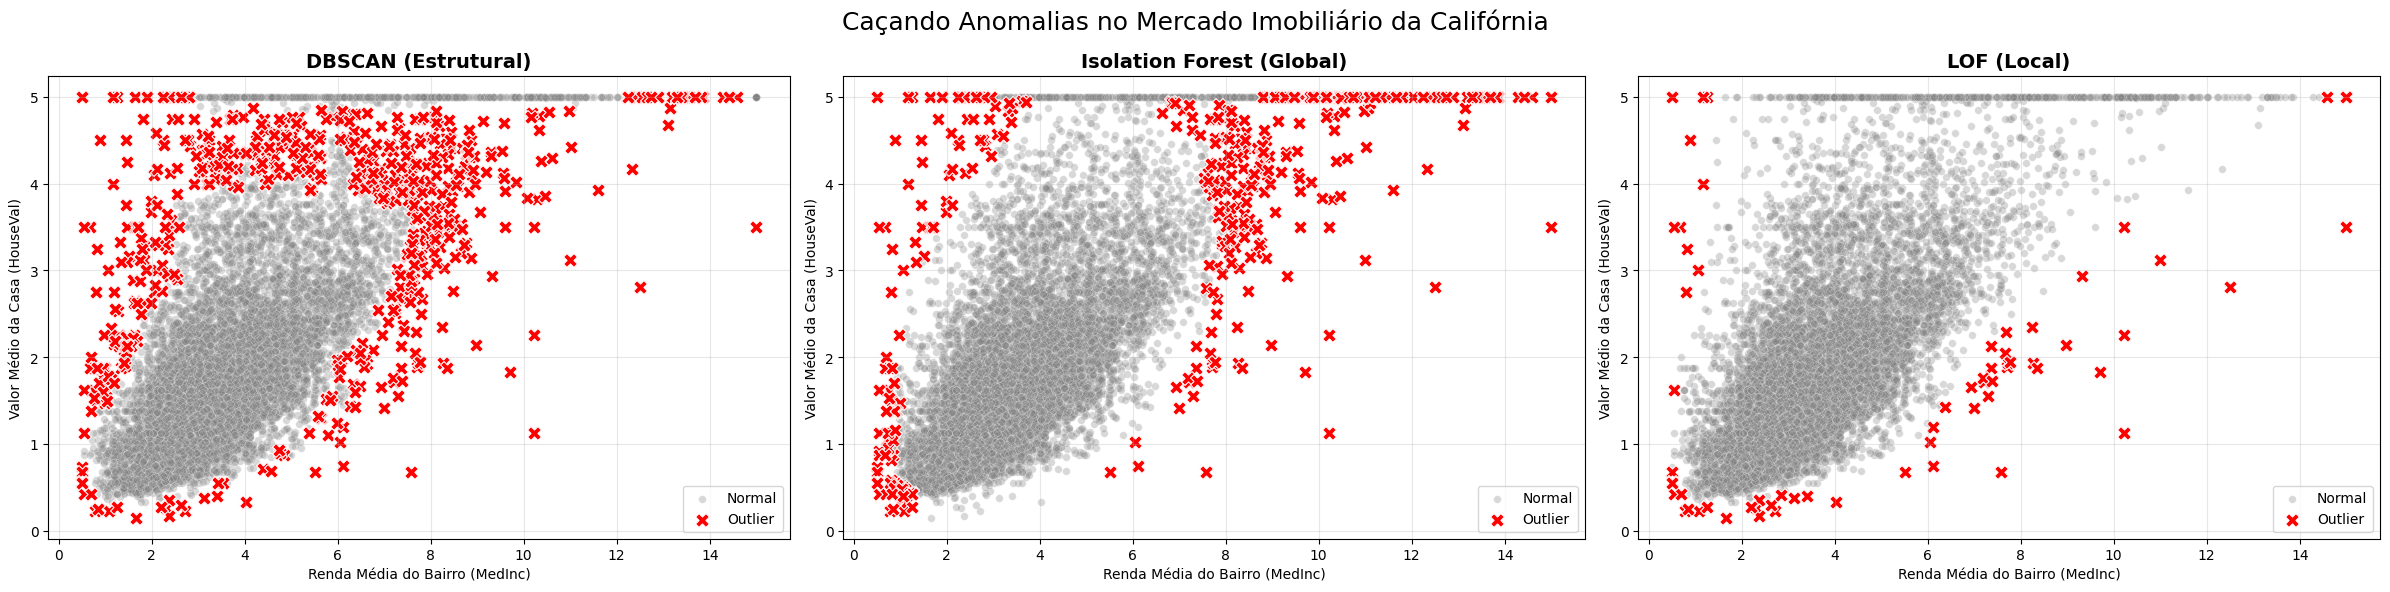

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Carregando o Dataset (Nativo do Scikit-Learn)
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
# Adicionando o Target (Valor da Casa)
df['HouseVal'] = california.target

# Amostragem (O dataset tem 20k linhas, vamos pegar 1000 para visualização ficar limpa)
# Random_state fixo para garantir que pegaremos os mesmos pontos na aula
df_sample = df.sample(n=10000, random_state=2024).copy()

# Selecionando as Variáveis: Renda Média (MedInc) vs Valor da Casa (HouseVal)
X = df_sample[['MedInc', 'HouseVal']]

# Pré-processamento: Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# APLICAÇÃO DOS MODELOS

# >>>DBSCAN
# eps=0.4: Ajuste fino para essa densidade
dbscan = DBSCAN(eps=0.1, min_samples=10)
df_sample['Outlier_DBSCAN'] = dbscan.fit_predict(X_scaled)

# >>>>Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=2024)
df_sample['Outlier_Iso'] = iso.fit_predict(X_scaled)

# >>>LOF
lof = LocalOutlierFactor(n_neighbors=100, contamination=0.01)
df_sample['Outlier_LOF'] = lof.fit_predict(X_scaled)

# VISUALIZAÇÃO
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Títulos e configurações
titulos = ['DBSCAN (Estrutural)', 'Isolation Forest (Global)', 'LOF (Local)']
cols_outlier = ['Outlier_DBSCAN', 'Outlier_Iso', 'Outlier_LOF']

for i, ax in enumerate(axes):
    col = cols_outlier[i]

    # Plotar Normais
    sns.scatterplot(data=df_sample[df_sample[col] != -1], x='MedInc', y='HouseVal',
                    color='gray', alpha=0.3, s=30, label='Normal', ax=ax)

    # Plotar Outliers
    sns.scatterplot(data=df_sample[df_sample[col] == -1], x='MedInc', y='HouseVal',
                    color='red', s=100, marker='X', label='Outlier', ax=ax)

    ax.set_title(titulos[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Renda Média do Bairro (MedInc)')
    ax.set_ylabel('Valor Médio da Casa (HouseVal)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Caçando Anomalias no Mercado Imobiliário da Califórnia', fontsize=18)
plt.tight_layout()
plt.show()



## Outlier em series temporais

Além dos recursos anteriores, podemos relacionar com o tempo.
A inspeção visual é sempre bem vinda, mas segue alguns recursos:

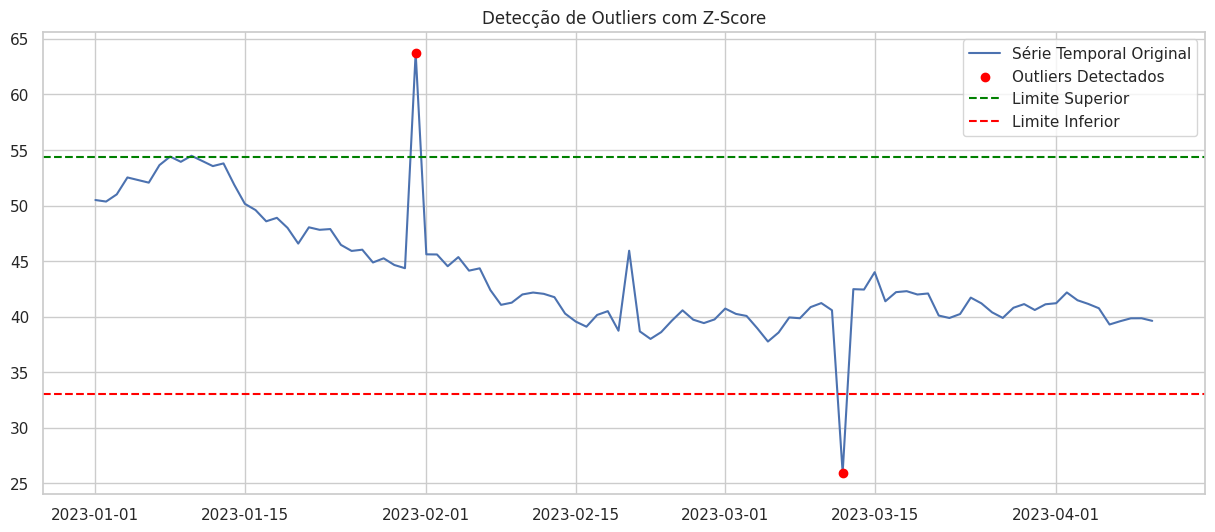

Outliers detectados nos seguintes pontos:
2023-01-31    63.753887
2023-03-12    25.931545
dtype: float64


In [ ]:
#>>>>> baseado no z-score(devio padrão)<<<<<<<
# >>>>limitado a identificar valores na escala global

# Criar uma série temporal
np.random.seed(42)
datas = pd.date_range(start='2023-01-01', periods=100, freq='D')
dados = np.random.randn(100).cumsum() + 50
serie_temporal = pd.Series(dados, index=datas)

# Introduzir  outlier
serie_temporal.iloc[30] = serie_temporal.iloc[30] + 20
serie_temporal.iloc[50] = serie_temporal.iloc[70] + 5
serie_temporal.iloc[70] = serie_temporal.iloc[70] - 15

# Calcular o Z-Score
media = serie_temporal.mean()
desvio_padrao = serie_temporal.std()
serie_zscore = (serie_temporal - media) / desvio_padrao

# Definir um limiar
limiar = 2.5
outliers = serie_temporal[abs(serie_zscore) > limiar]
upper_bound_rolling_sd =media + 2 *desvio_padrao
lower_bound_rolling_sd =media - 2* desvio_padrao

# Visualização
plt.figure(figsize=(15, 6))
plt.plot(serie_temporal, label='Série Temporal Original')
plt.scatter(outliers.index, outliers.values, color='red', label='Outliers Detectados', zorder=5)
plt.axhline(y=upper_bound_rolling_sd , color='green', linestyle='--', label='Limite Superior')
plt.axhline(y=lower_bound_rolling_sd, color='red', linestyle='--', label='Limite Inferior')
plt.title('Detecção de Outliers com Z-Score')
plt.legend()
plt.grid(True)
plt.show()

print("Outliers detectados nos seguintes pontos:")
print(outliers)

## atividade

Como podemos detectar o outlier que não foi detecdado no exercicio anterior, com emprego de medias por bloco ou moveis.

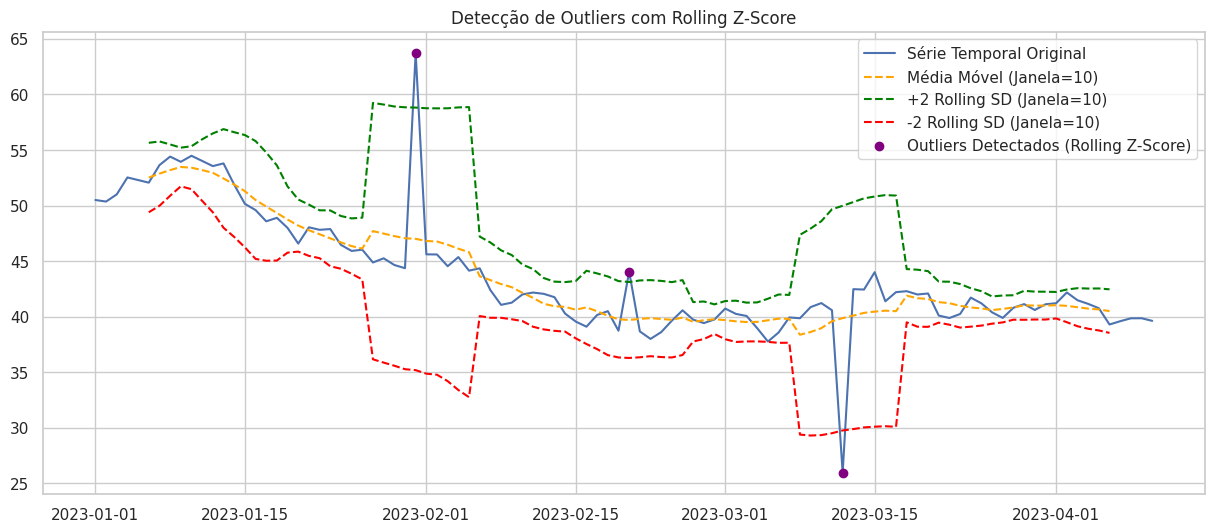

Outliers detectados nos seguintes pontos (Rolling Z-Score com limiar 2.0):
2023-01-31    63.753887
2023-02-20    44.050389
2023-03-12    25.931545
dtype: float64


In [ ]:
# >>>>> baseado no z-score (desvio padrão móvel) <<<<<<<
# >>>> identifica outliers em janelas locais

np.random.seed(42)
datas = pd.date_range(start='2023-01-01', periods=100, freq='D')
dados = np.random.randn(100).cumsum() + 50
serie_temporal_rolling = pd.Series(dados, index=datas)

# Introduzir outliers
serie_temporal_rolling.iloc[30] = serie_temporal_rolling.iloc[30] + 20
serie_temporal_rolling.iloc[50] = serie_temporal_rolling.iloc[50] + 5 # Outlier menor
serie_temporal_rolling.iloc[70] = serie_temporal_rolling.iloc[70] - 15 # Outlier negativo

# Definir o tamanho da janela para o cálculo da média e desvio padrão móvel
window_size = 10

# Calcular a média móvel e o desvio padrão móvel
rolling_mean = serie_temporal_rolling.rolling(window=window_size, center=True).mean()
rolling_std = serie_temporal_rolling.rolling(window=window_size, center=True).std()

# calculo os pontos de corte upper(superior) e lower(inferior) para o grafico
upper_bound_rolling_sd = rolling_mean + 2 * rolling_std
lower_bound_rolling_sd = rolling_mean - 2 * rolling_std

# Calcular o Z-Score móvel
# Evita divisão por zero onde rolling_std é 0 (janelas com valores constantes)
rolling_zscore = (serie_temporal_rolling - rolling_mean) / rolling_std.replace(0, np.nan)


# Definir um limiar para detecção de outliers
# Geralmente um pouco menor que o Z-score global (2.5 a 3)
limiar_rolling = 2.0
outliers_rolling = serie_temporal_rolling[abs(rolling_zscore) > limiar_rolling]

# Visualização
plt.figure(figsize=(15, 6))
plt.plot(serie_temporal_rolling, label='Série Temporal Original')
plt.plot(rolling_mean, label=f'Média Móvel (Janela={window_size})', color='orange', linestyle='--')
plt.plot(upper_bound_rolling_sd, label=f'+2 Rolling SD (Janela={window_size})', color='green', linestyle='--')
plt.plot(lower_bound_rolling_sd, label=f'-2 Rolling SD (Janela={window_size})', color='red', linestyle='--')
plt.scatter(outliers_rolling.index, outliers_rolling.values, color='purple', label='Outliers Detectados (Rolling Z-Score)', zorder=5)
plt.title('Detecção de Outliers com Rolling Z-Score')
plt.legend()
plt.grid(True)
plt.show()

print(f"Outliers detectados nos seguintes pontos (Rolling Z-Score com limiar {limiar_rolling}):")
print(outliers_rolling)

## identificação pelo Residuo da decomposição

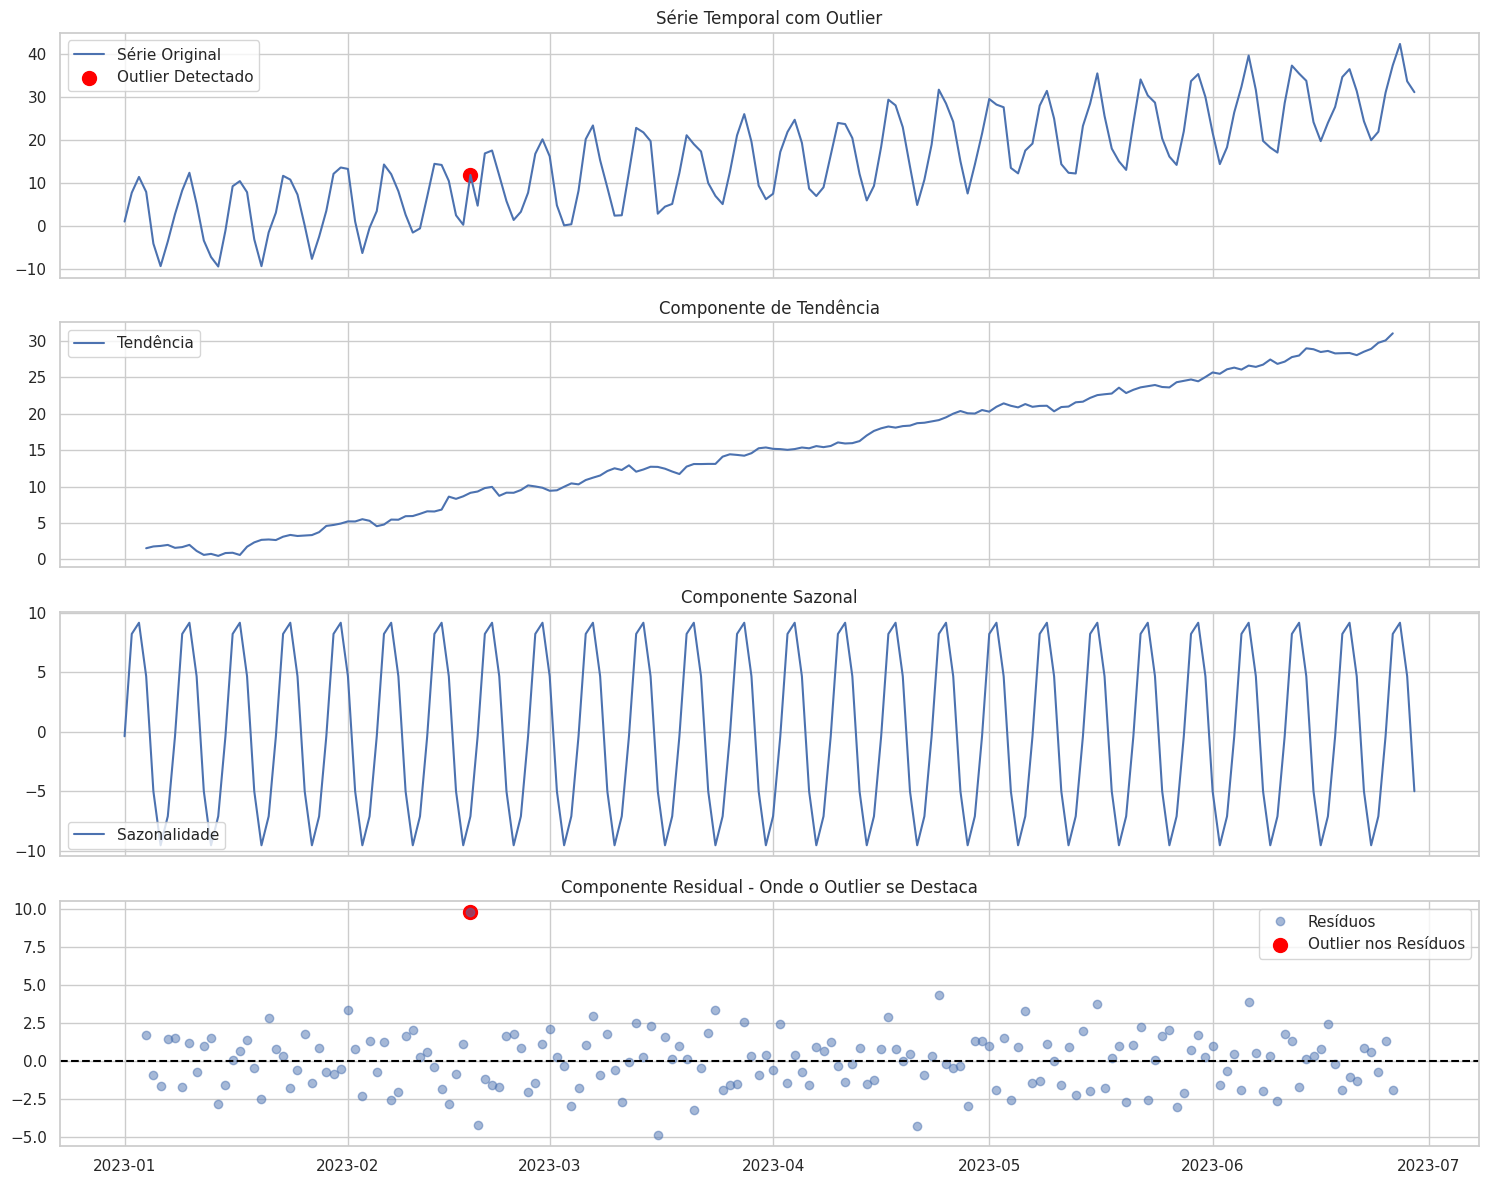

Índice do outlier detectado: DatetimeIndex(['2023-02-18'], dtype='datetime64[ns]', freq='D')


In [ ]:
# Analise dos Residuos
from statsmodels.tsa.seasonal import seasonal_decompose

# Cria uma série temporal sintética com tendência e sazonalidade
np.random.seed(42)
datas = pd.date_range(start='2023-01-01', periods=180, freq='D')

# Tendência linear
tendencia = np.linspace(0, 30, 180)

# Sazonalidade semanal (padrão se repete a cada 7 dias)
sazonalidade = 10 * np.sin(np.arange(180) * 2 * np.pi / 7)

# Ruído aleatório
ruido = np.random.normal(0, 2, 180)

# Série original = Tendência + Sazonalidade + Ruído
serie_original = pd.Series(tendencia + sazonalidade + ruido, index=datas)

# Inserir um outlier claro
# Este valor seria um outlier óbvio nos resíduos, mas talvez não tão óbvio na série original
serie_com_outlier = serie_original.copy()
serie_com_outlier.iloc[48] = serie_com_outlier.iloc[50] -5 # Adiciona um pico anômalo

# Decompor a série temporal
# Usamos um modelo aditivo porque a sazonalidade parece ter uma amplitude constante
# O 'period=7' informa que o ciclo sazonal é de 7 dias.
decomposicao = seasonal_decompose(serie_com_outlier, model='additive', period=7)

# Extrai os resíduos. A decomposição pode gerar NaNs no início/fim, então os removemos.
residuos = decomposicao.resid.dropna()

# Aplica Z-Score nos resíduos
media_residuos = residuos.mean()
std_residuos = residuos.std()
residuos_zscore = (residuos - media_residuos) / std_residuos

# Definir um limiar para detecção
limiar = 3.0
indices_outliers = residuos[abs(residuos_zscore) > limiar].index

#Visualização completa
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Gráfico 1: Série Original com Outlier
ax1.plot(serie_com_outlier, label='Série Original')
ax1.scatter(indices_outliers, serie_com_outlier[indices_outliers], color='red', s=100, label='Outlier Detectado')
ax1.set_title('Série Temporal com Outlier')
ax1.legend()
ax1.grid(True)

# Gráfico 2: Tendência
ax2.plot(decomposicao.trend, label='Tendência')
ax2.set_title('Componente de Tendência')
ax2.legend()
ax2.grid(True)

# Gráfico 3: Sazonalidade
ax3.plot(decomposicao.seasonal, label='Sazonalidade')
ax3.set_title('Componente Sazonal')
ax3.legend()
ax3.grid(True)

# Gráfico 4: Resíduos
ax4.plot(residuos, label='Resíduos', marker='o', linestyle='None', alpha=0.5)
ax4.scatter(indices_outliers, residuos[indices_outliers], color='red', s=100, label='Outlier nos Resíduos')
ax4.axhline(0, color='black', linestyle='--')
ax4.set_title('Componente Residual - Onde o Outlier se Destaca')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

print("Índice do outlier detectado:", indices_outliers)


## Deriva

Mudança gradual na característica da serie temporal, pode ser identificado de maneira global pelo ADF (teste de estacionalidade), porem podemos identificar localmente com uso de medias moveis, observando algumas métricas de variabilidade.

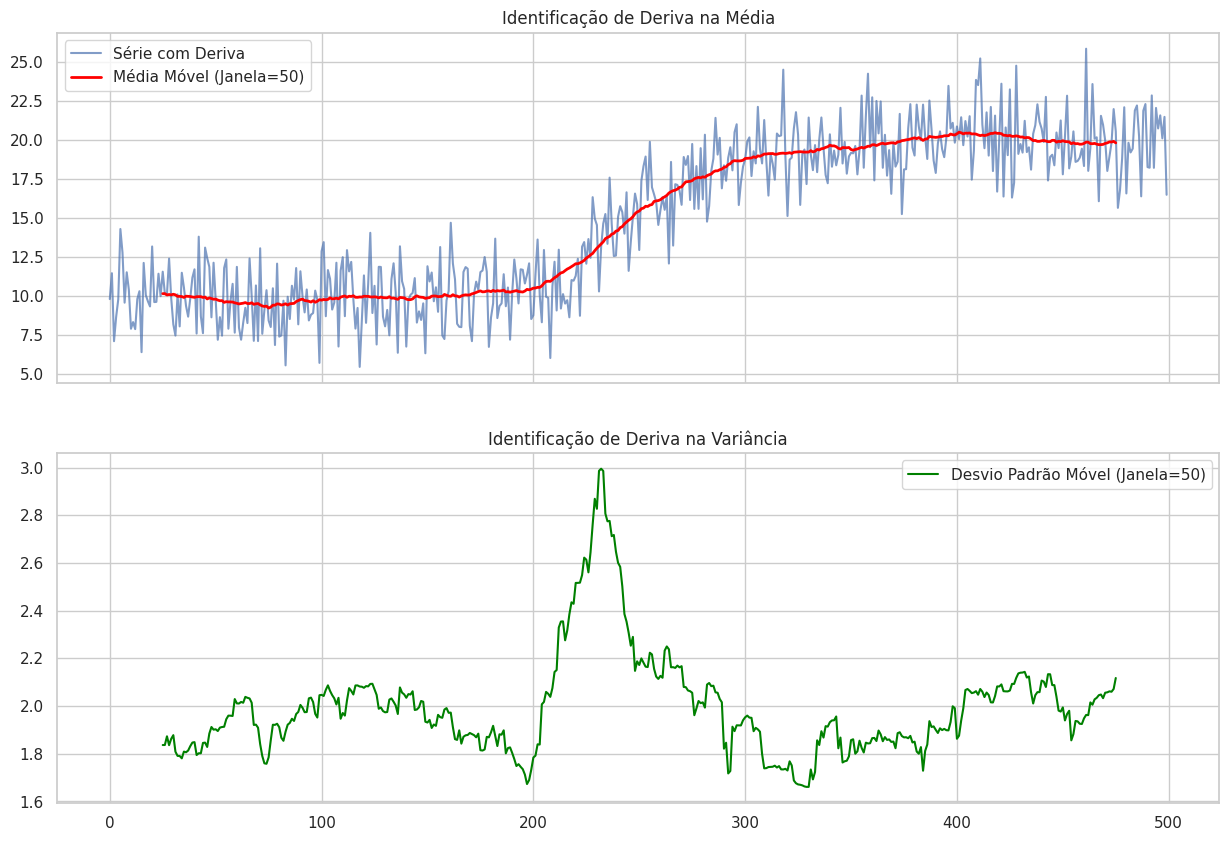

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cria uma série com deriva na média
np.random.seed(2025)
periodo1 = np.random.normal(loc=10, scale=2, size=200)
# A deriva: uma transição gradual
transicao = np.linspace(10, 20, 100) + np.random.normal(scale=2, size=100)
periodo2 = np.random.normal(loc=20, scale=2, size=200)

dados_com_deriva = np.concatenate([periodo1, transicao, periodo2])
serie_com_deriva = pd.Series(dados_com_deriva)

# Calcular a média móvel com uma janela de 50 pontos
media_movel = serie_com_deriva.rolling(window=50, center=True).mean()
std_movel = serie_com_deriva.rolling(window=50, center=True).std()

# Visualização, observe o valor elevado de variancia no periodo de deriva
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax[0].plot(serie_com_deriva, label='Série com Deriva', alpha=0.7)
ax[0].plot(media_movel, label='Média Móvel (Janela=50)', color='red', linewidth=2)
ax[0].set_title('Identificação de Deriva na Média')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(std_movel, label='Desvio Padrão Móvel (Janela=50)', color='green')
ax[1].set_title('Identificação de Deriva na Variância')
ax[1].legend()
ax[1].grid(True)

plt.show()

## Descontinuidade

Diferente da deriva a descontinuidade da um salto para uma novo padrão, o que torna a identifação mais facil.

In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.3 MB/s eta 0:00:00


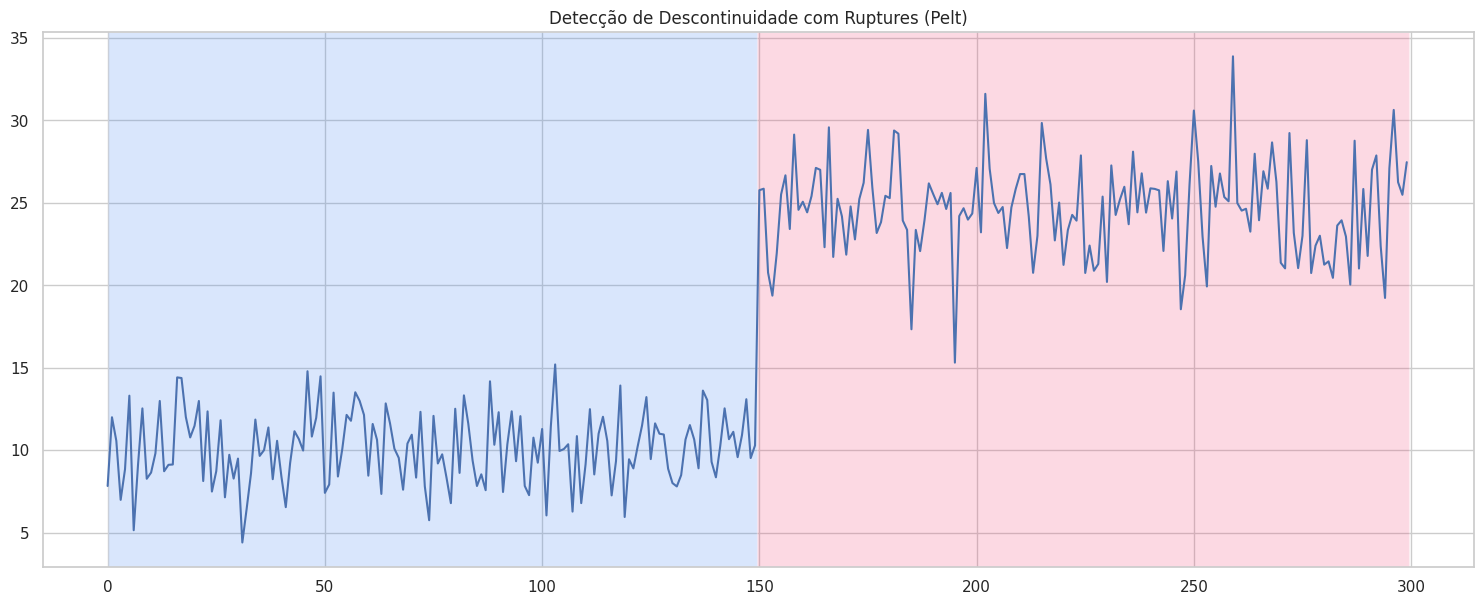

Ponto de mudança detectado no índice: 150


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

# Criar uma série com uma mudança abrupta (descontinuidade)
np.random.seed(123)
periodo1 = np.random.normal(loc=10, scale=2, size=150)
# Mudança abrupta
periodo2 = np.random.normal(loc=25, scale=3, size=150)

dados_com_descontinuidade = np.concatenate([periodo1, periodo2])
pontos = np.array(dados_com_descontinuidade).reshape(-1, 1) # Ruptures espera um array 2D

# Detecção do ponto de mudança
# Usando o algoritmo Pelt com um modelo de custo baseado em Erro Quadrático Mínimo ("l2")
algo = rpt.Pelt(model="l2").fit(pontos)
resultado = algo.predict(pen=200) # 'pen' é uma penalidade para evitar excesso de pontos, quanto maior, mais criterioso

# Visualização
fig, (ax,) = rpt.display(pontos, resultado, figsize=(15, 6))
ax.set_title('Detecção de Descontinuidade com Ruptures (Pelt)')
plt.show()

print(f"Ponto de mudança detectado no índice: {resultado[0]}")

In [ ]:
# saber feridos pode ser um ponto de outliers, vesperar idem
import holidays # não tem municipais e estaduais

# especificar o pais e os anos
country = 'BR'  # Brazil
years = [2023, 2024, 2025, 2026]

#criar o objeto
all_holidays = holidays.CountryHoliday(country, years=years, state= "RS")

for date, name in sorted(all_holidays.items()):
    print(f"{date}: {name}")

2023-01-01: Universal Fraternization Day
2023-04-07: Good Friday
2023-04-21: Tiradentes' Day
2023-05-01: Worker's Day
2023-09-07: Independence Day
2023-09-20: Gaucho Day
2023-10-12: Our Lady of Aparecida
2023-11-02: All Souls' Day
2023-11-15: Republic Proclamation Day
2023-12-25: Christmas Day
2024-01-01: Universal Fraternization Day
2024-03-29: Good Friday
2024-04-21: Tiradentes' Day
2024-05-01: Worker's Day
2024-09-07: Independence Day
2024-09-20: Gaucho Day
2024-10-12: Our Lady of Aparecida
2024-11-02: All Souls' Day
2024-11-15: Republic Proclamation Day
2024-11-20: National Day of Zumbi and Black Awareness
2024-12-25: Christmas Day
2025-01-01: Universal Fraternization Day
2025-04-18: Good Friday
2025-04-21: Tiradentes' Day
2025-05-01: Worker's Day
2025-09-07: Independence Day
2025-09-20: Gaucho Day
2025-10-12: Our Lady of Aparecida
2025-11-02: All Souls' Day
2025-11-15: Republic Proclamation Day
2025-11-20: National Day of Zumbi and Black Awareness
2025-12-25: Christmas Day
2026-01

## Como Proceder ao identificar um outlier (Estratégias de Tratamento)

Ao identificar outliers, o Cientista de Dados deve tomar uma decisão baseada no algoritmo que será usado e na natureza do dado.

### Estratégia 1: Remoção (Trimming)
* **Ação:** Excluir as linhas que contêm outliers.
* **Quando usar:** Quando o outlier é claramente um erro de dado (ex: Idade = 500 anos) ou quando o dataset é grande o suficiente para suportar a perda de informações.

### Estratégia 2: Limitação (Capping / Winsorization)
* **Ação:** Substituir o valor do outlier pelo valor do limite máximo ou mínimo calculado.
* **Exemplo:** Se o limite superior do IQR é 100 e o valor é 500, altera-se o valor para 100.
* **Quando usar:** Quando queremos manter a linha de dados para não perder as outras colunas, mas precisamos suavizar o impacto extremo daquela variável específica (Vital para KNN e Regressão Linear).

### Estratégia 3: Transformação Logarítmica
* **Ação:** Aplicar logaritmo (Log10 ou Ln) na coluna inteira.
* **Quando usar:** Quando os dados têm magnitudes exponenciais (ex: Salários, Preços de Imóveis).
* **Efeito:** O logaritmo reduz drasticamente a distância entre os valores extremos e a média, trazendo o outlier para "perto" do grupo sem removê-lo.

### Estratégia 4: Manutenção (Não fazer nada)
* **Ação:** Deixar o dado como está, porem criar um flag para indica-lo, é bem vindo.
* **Quando usar:** 1. Se estiver usando modelos baseados em Árvores, que lidam bem com outliers.
    2. Se o objetivo do projeto for Detecção de Anomalias (Fraude), onde o outlier é justamente o que procuramos.